<a href="https://colab.research.google.com/github/Joe95009/RBIF125_Final_JO_New/blob/main/RBIF125_Final0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the colon pathology dataset from Medminst library

In [1]:
%pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.2 MB/s eta 0:00:00


In [14]:
import medmnist
from medmnist import PathMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Transform RGB images to tensors and normalize
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 1. Download and load the datasets
train_dataset = PathMNIST(split='train', transform=data_transform, download=True)
val_dataset = PathMNIST(split='val', transform=data_transform, download=True)
test_dataset = PathMNIST(split='test', transform=data_transform, download=True)

# 2. Wrap them in PyTorch DataLoaders for your model
batch_size = 256
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

Load pre-trained torch model for image analysis (resnet.18)

In [15]:
import torch
import torchvision.models as models
import torch.nn as nn

#Downlaod model
model = models.resnet18(weights="DEFAULT")

#Create custom classification head for resnet18 model
num_classes = 9
model.fc = nn.Sequential(nn.Linear(model.fc.in_features, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes))

In [16]:
print(model.fc)

Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=9, bias=True)
)


Set the device to cuda which should allow the model to run using the GPU

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{device}") # This should print 'cuda'

cuda


In [18]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


Train the pre-trained torch model(ResNet18) using the colon image training set from Medminst

In [20]:
import torch.optim as optim
from tqdm import tqdm

#Run model using the GPU
model = model.to(device)

#Define loss function (using CrossEntropyLoss from multiclass classification loss) and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

train_losses = []
top_val_accuracy = 0.0

num_epochs=5
for epoch in range(num_epochs):
 # Iterate over training batches
   print(f"Epoch [{epoch + 1}/{num_epochs}]")
   running_loss = 0.0
   #Put model in train mode
   model.train()

   for batch_index, (data, targets) in enumerate(tqdm(train_loader)):
       data = data.to(device)
       targets = targets.squeeze().long().to(device)
       optimizer.zero_grad()
       scores = model(data)
       loss = criterion(scores, targets)
       loss.backward()
       optimizer.step()

       running_loss += loss.item() * data.size(0)

   epoch_loss = running_loss / len(train_loader.dataset)
   train_losses.append(epoch_loss)

   print(f"  Train loss: {epoch_loss:.4f}")

   #Put model in evaluation phase fro validation of each epoch
   model.eval()
   correct = 0.0
   total = 0.0

   with torch.no_grad():
    for data, targets in val_loader:
        data = data.to(device)
        targets = targets.squeeze().long().to(device)

        # Grab the logits from the model ouput
        scores = model(data)
        #Define predictions
        predictions = torch.argmax(scores, dim=1)
        # Count how many predictions matched the true targets
        correct += (predictions == targets).sum().item()
        total += targets.size(0)

    accuracy = (correct / total) * 100
    print(f"Validation Accuracy: {accuracy:.2f}%")

    #Save the best model epoch based on validation accuracy
    if accuracy > top_val_accuracy:
      top_val_accuracy = accuracy
      torch.save(model.state_dict(), "top_model.pth")
      print("New top model")


Epoch [1/5]


100%|██████████| 352/352 [06:47<00:00,  1.16s/it]


  Train loss: 0.0256
Validation Accuracy: 98.74%
New top model
Epoch [2/5]


100%|██████████| 352/352 [07:09<00:00,  1.22s/it]


  Train loss: 0.0173
Validation Accuracy: 98.46%
Epoch [3/5]


...

  Train loss: 0.0118
Validation Accuracy: 98.95%
New top model
Epoch [4/5]


100%|██████████| 352/352 [07:04<00:00,  1.21s/it]


  Train loss: 0.0127
Validation Accuracy: 98.04%
Epoch [5/5]


100%|██████████| 352/352 [07:03<00:00,  1.20s/it]


  Train loss: 0.0106
Validation Accuracy: 98.41%


Plot loss vs epochs

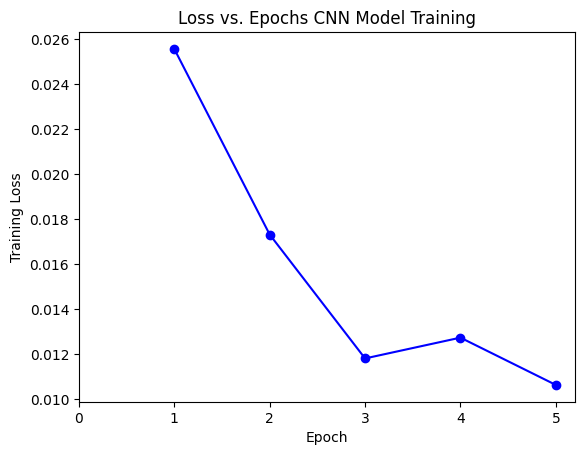

In [26]:
import matplotlib.pyplot as plt
#set x and y
x = (range(1, num_epochs+1))
y = train_losses

#Create plot
plt.plot(x, y, color = "blue", linestyle = '-', marker = 'o')
plt.xticks(np.arange(0, 6, step=1))

#Add labels
plt.title("Loss vs. Epochs CNN Model Training")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.show()

Load best model based on validation accuracy

In [22]:
model.load_state_dict(torch.load("top_model.pth"))

<All keys matched successfully>

Test the model on the test set and calculate performance metrics

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

# Use pytorch evalution mode
model.eval()

correct = 0
total = 0

total_predictions = []
total_targets = []
# Run pytorch with no graideints for faster processing
with torch.no_grad():
    for data, targets in test_loader:
        data = data.to(device)
        targets = targets.squeeze().long().to(device)

        # Grab the logits from the model ouput
        scores = model(data)

        #Define predictions
        predictions = torch.argmax(scores, dim=1)

        #Flatten taregts and predictions and move to cpu for scikitlearn
        total_predictions.extend(predictions.cpu().numpy().flatten())
        total_targets.extend(targets.cpu().numpy().flatten())


        # Count how many predictions matched the true targets
        total += targets.size(0)
        correct += (predictions == targets).sum().item()

#Calculate accuarcy, F1, recall
test_accuracy = (correct / total) * 100
precision = precision_score(total_targets, total_predictions, average="macro")
f1 = f1_score(total_targets, total_predictions, average="macro")
recall = recall_score(total_targets, total_predictions, average="macro")
print(f"Test Accuracy: {test_accuracy: .2f}%")
print(f"Precision Score: {precision: .2f}")
print(f"F1 Score: {f1: .2f}")
print(f"Recall: {recall: .2f}")

Test Accuracy:  90.01%
Precision Score:  0.89
F1 Score:  0.88
Recall:  0.88


Generate a confusiuon matrix to visualize test results

Text(0.5, 1.0, 'Model Test Performance Confusion Matrix')

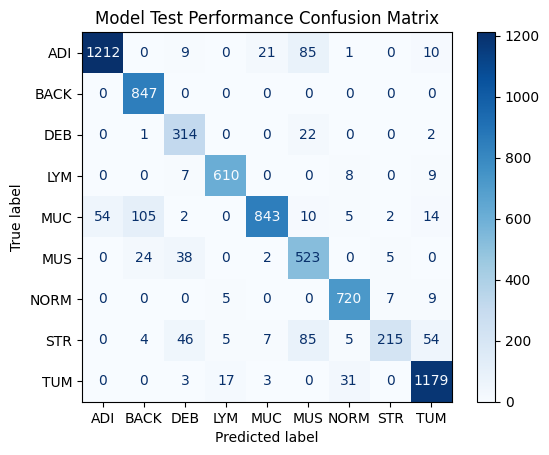

In [27]:
#Make confusion matrix
cm = confusion_matrix(total_targets, total_predictions)

#Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Model Test Performance Confusion Matrix")